# Determining the Best Neighborhood in Pittsburgh

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# walkability
walk = pd.read_csv("https://pghgishub-pittsburghpa.opendata.arcgis.com/datasets/3ca13246362540fa8b4b567f84a1255b_0.csv?outSR=%7B%22latestWkid%22%3A6565%2C%22wkid%22%3A103142%7D")

# accessibility
playground = pd.read_csv("https://data.wprdc.org/datastore/dump/e39ef76e-0a11-47c8-a86f-a37f55db7a2b")

# cosmetics
art = pd.read_csv("https://data.wprdc.org/datastore/dump/00d74e83-8a23-486e-841b-286e1332a151")


## Introduction: 
To determine the best neighborhood in the City of Pittsburgh, we each found a dataset and analyzed it to come up with a conclusion that we thought was most meaningful to us. First, we cleaned it to only use the relevant columns as each dataset had numerous columns that were not meaningful to us such as size of the neighborhood. Then, we ranked our findings from highest to greatest and looked more deeply into the top 10 neighborhoods of each of our datasets. When we encountered more than 2 valuable datasets, we used a point system to calculate a score and then rank the scores which gives a more holistic picture of the variable we are measuring. While we were debating between a few datasets such as air quality and bus transit, we ultimately chose walkability, playground accessibility, and public art. 


## Our Metric: 
We decided our metric to be Quality of Life. This encompasses everything from neighborhood wellbeing, and physical, environmental, and social factors. From this, we had three submetrics: Convenience, Accessibility, and Cosmetics. For the Convenience submetric, we used the “Neighborhood with SNAP Data” dataset, where we measured walkability, how convenient a neighborhood is to walk around in. For the Accessibility submetric, we used the “Playground Equipment” dataset, where we determined which playgrounds had the most ADA accessible playgrounds. Finally, for the Cosmetics submetric, we looked at how many works of public art a neighborhood had.


## The Best Neighborhood Analysis
### Vaisalli - Convenience

To figure out what the best neighborhood in the City of Pittsburgh is, I personally looked at the walkability. I think this dataset is crucial when looking at how convenient the neighborhood is in terms of how easy it is to get around the neighborhood and how well it promotes a healthy lifestyle. This directly correlates with our overall metric: Quality of life. 


However, one issue I constantly faced was that these datasets were not all on the same scale of 0-1. Thus, the score calculated was not accurate. To fix this issue, I normalized the data by using this formula: 


This formula creates a score from 0-1 and is a relative score compared to the other neighborhoods which incorporates more context into the score. 
Finally, I ranked all the data and created a visualization to share my findings in a friendly method. 

             Neighborhood  walk_score
          Central Oakland    0.570393
                    Bluff    0.546977
Central Business District    0.526633
           East Allegheny    0.487179
            North Oakland    0.485216
              North Shore    0.416949
             West Oakland    0.410179
            South Oakland    0.388152
        Central Northside    0.366177
         Allegheny Center    0.365966
               Bloomfield    0.359788
               Friendship    0.345765
           Allegheny West    0.340007
         Duquesne Heights    0.321309
            Spring Garden    0.308170
                Knoxville    0.302458
          Terrace Village    0.297281
             East Liberty    0.288026
                Beechview    0.285461
               Manchester    0.281610
                 Garfield    0.270865
         Crawford-Roberts    0.267649
               Mt. Oliver    0.264713
      Squirrel Hill North    0.264589
         South Side Flats    0.257253
            

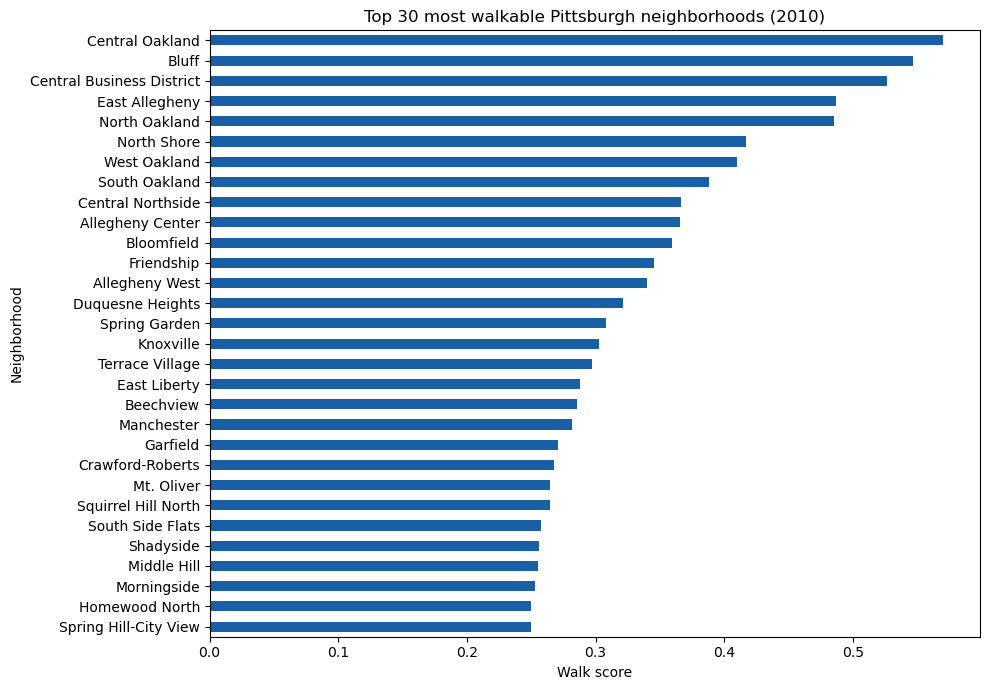

In [15]:
#convert to numeric data
def clean(col):
    return pd.to_numeric(col.astype(str).str.replace('%', ''), errors='coerce')

walk['walk_to_work'] = clean(walk['Commute to Work: Walk (2010)'])
walk['street_density'] = clean(walk['Street Density (st. mi/area sq. mi)'])
walk['greenway'] = clean(walk['Greenway (% of land area)'])

# Normalizing dataset
def normalize(col):
    return (col - col.min()) / (col.max() - col.min())

walk['walk_to_work'] = normalize(walk['walk_to_work'])
walk['street_density'] = normalize(walk['street_density'])
walk['greenway'] = normalize(walk['greenway'])

# Walking Score
walk['walk_score'] = (walk['walk_to_work'] * 0.4) + (walk['street_density'] * 0.4) + (walk['greenway'] * 0.2)

most_walkable = walk[['Neighborhood', 'walk_score']].sort_values('walk_score', ascending=False).head(30)
print(most_walkable.to_string(index=False))

#Table and Graph
top30 = walk[['Neighborhood', 'walk_score']].sort_values('walk_score', ascending=False).head(30).set_index('Neighborhood')['walk_score'].sort_values()

top30.plot(kind='barh', color='#185FA5', figsize=(10, 7))
plt.xlabel('Walk score')
plt.title('Top 30 most walkable Pittsburgh neighborhoods (2010)')
plt.tight_layout()
plt.show()

From this visualization, Central Oaklands ranks as number one in terms of Convenience (walkability).

### Raima - Accessibility

To figure out the best Pittsburgh neighborhood, I looked at the accessibility of various playground equipment in parks in Pittsburgh neighborhoods. I cleaned the data by dropping 11-12 columns and dealing with blank/null values. For my first visualization. I looked at how many ADA accessible playgrounds existed in each neighborhood and plotted that. I did this by applying a query mask to the ada_accessible column and plotting the number of occurrences by neighborhood. As you can see, Squirrel Hill South is rated first.

In [21]:
# data cleaning
playground = playground.drop(columns=['ward','_id', 'id','street', 'street_number', 'council_district', 'tract', 'public_works_division', 'pli_division', 'police_zone', 'fire_zone', 'latitude', 'longitude'])
playground.fillna(0)

# which neighborhoods have playground equipment that is ADA accessible?
ada_mask = playground["ada_accessible"] == "t"
ada_df = playground[playground['ada_accessible'] == 't']

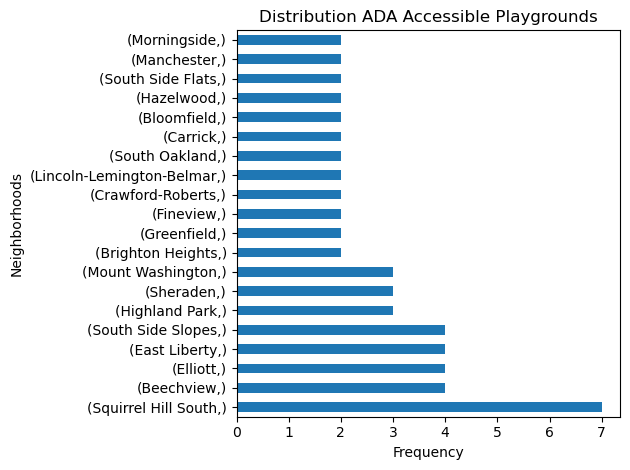

In [22]:
# plotting to see which neighborhoods have the most ada_accessible playgrounds

ada_plot = ada_df[["neighborhood"]].value_counts().head(20)

# Plot (kind='bar' for grouped, add stacked=True for a stacked bar)
ada_plot.plot(kind='barh', ax=plt.gca())

# Formatting
plt.title("Distribution ADA Accessible Playgrounds")
# plt.figure(figsize=(10, 15)) 
plt.xlabel("Frequency")
plt.ylabel("Neighborhoods")
# plt.legend(title="Legend", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Additionally, I also looked at the type of safety surfaces present in each playground. At a high level, they all serve the same purpose, but Pour in Place/SofSurfaces (Pour in Place is often branded as SofSurfaces) is a higher cost, more durable material that requires little maintenance and retains its form. Engineered Wood Fiber, on the other hand, is cheaper but harder to navigate as it ages, making it harder for wheelchair users to traverse. As such, I looked to see which neighborhoods had more playgrounds with Pour in Place/SofSurfaces as their safety surface. Again, Squirrel Hill South is ranked first, making this the best neighborhood in terms of accessibility for playgrounds.

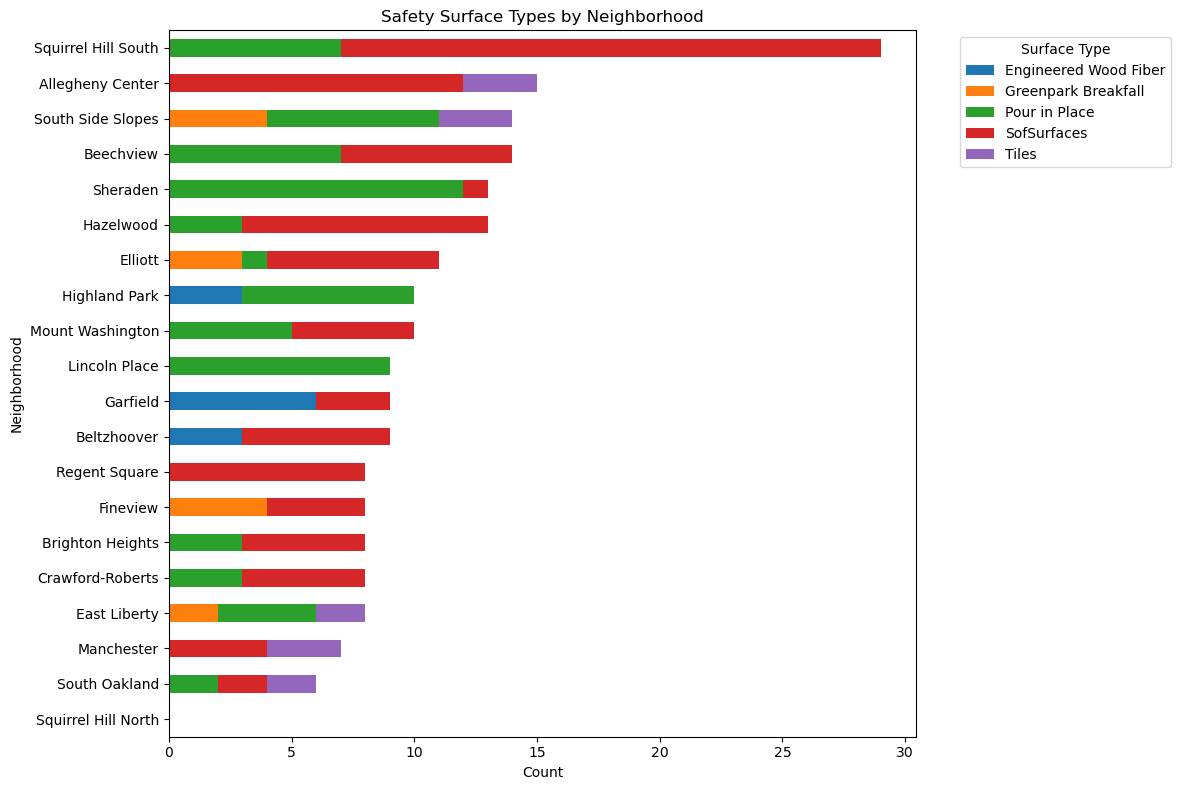

In [23]:
surface_pivot = pd.crosstab(playground['neighborhood'], playground['safety_surface_type'])

# Let's see the top 20 neighborhoods to keep the plot clean
top_20_neighborhoods = playground['neighborhood'].value_counts().head(20).index
plot_data = surface_pivot.reindex(top_20_neighborhoods, fill_value=0)

# Plotting
plt.figure(figsize=(12, 8))
plot_data = surface_pivot.reindex(top_20_neighborhoods, fill_value=0)
plot_data = plot_data.assign(total=plot_data.sum(axis=1)).sort_values('total', ascending=True).drop(columns='total')
plot_data.plot(kind='barh', stacked=True, ax=plt.gca())

plt.title("Safety Surface Types by Neighborhood")
plt.xlabel("Count")
plt.ylabel("Neighborhood")
plt.legend(title="Surface Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Katie - Cosmetics

The dataset that I used for my project was about Pittsburgh public art. I chose this as my dataset because I believe that art shows a lot about a neighborhood. There were different types of art shown in the dataset which includes, historical art, monuments, contemporary art, non-city owned art, and memorials. For a neighborhood to be considered best, or even good it should have a combination of all these types of art, this is to ensure that it accurately portrays Pittsburgh. To figure out the best neighborhood in Pittsburgh based off my dataset I had to clean up the data by sorting it alphabetically in order to get all of the same neighborhood art together. 


In [39]:
art_sort = art.sort_values(by='neighborhood')
art_sort

,_id,id,name,title,artist_name,art_type,park,image,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude
123,124,1790632922,WM00003000,Hampton Battery Memorial,Unknown,War Memorials,Allegheny Commons,https://tools.wprdc.org/images/pittsburgh/art_...,Allegheny Center,1.0,22.0,4.200356e+10,1.0,22.0,1.0,1-20,40.450890,-80.000960
54,55,1175269324,PA00049000,The Heavens,Sidney Waugh,Historic Art,NaN,NaN,Allegheny Center,1.0,22.0,4.200356e+10,1.0,22.0,1.0,1-6,40.452607,-80.006404
55,56,1971852534,PA00050000,The Earth,Sidney Waugh,Historic Art,NaN,NaN,Allegheny Center,1.0,22.0,4.200356e+10,1.0,22.0,1.0,1-6,40.452607,-80.006107
56,57,1492179153,PA00051000,Night,Sidney Waugh,Historic Art,NaN,NaN,Allegheny Center,1.0,22.0,4.200356e+10,1.0,22.0,1.0,1-6,40.452908,-80.006603
57,58,1663151283,PA00052000,Day,Sidney Waugh,Historic Art,NaN,NaN,Allegheny Center,1.0,22.0,4.200356e+10,1.0,22.0,1.0,1-6,40.453007,-80.006107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,91,431608558,PA00107002,Lawrenceville Life Links,JoAnna Commandaros,Modern and Contemporary Art,NaN,NaN,Upper Lawrenceville,7.0,10.0,4.200310e+10,2.0,10.0,2.0,3-5,40.479358,-79.954913
185,186,1597478051,WM00068000,War Memorial (West End),NaN,War Memorials,NaN,NaN,West End,2.0,20.0,4.200356e+10,5.0,20.0,6.0,1-17,40.440180,-80.034215
17,18,1873659637,175,Police Department Zone 6 Mural,"Ed Wirkowski, Michael Kapeluck, & Robert Robinson",Modern and Contemporary Art,NaN,NaN,West End,2.0,20.0,4.200356e+10,5.0,20.0,6.0,1-17,40.442081,-80.032174
6,7,915929762,156,Windows of Light,Jane Haskell,Modern and Contemporary Art,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


I then grouped the data together by the name of the neighborhood and the type of art, which would then be placed into the graph as I wanted to see the variety of art each neighborhood had as not every neighborhood had the same type of art.


In [40]:
art_pivot = pd.crosstab(art['neighborhood'], art['art_type'])

Finally the data was then sorted by how much of each type of art each neighborhood had. This allowed for me to see what the scale was for each area, which showed which neighborhoods were lacking in art and which weren’t.

In [41]:
art_pivot['Total Art'] = art_pivot.sum(axis=1)
sorted_art = art_pivot.sort_values(by='Total Art')

I made sure that each bar in the graph would be color coded based on the type of art that it had, which would allow the user to easily be able to see how much of each type of art every neighborhood had.


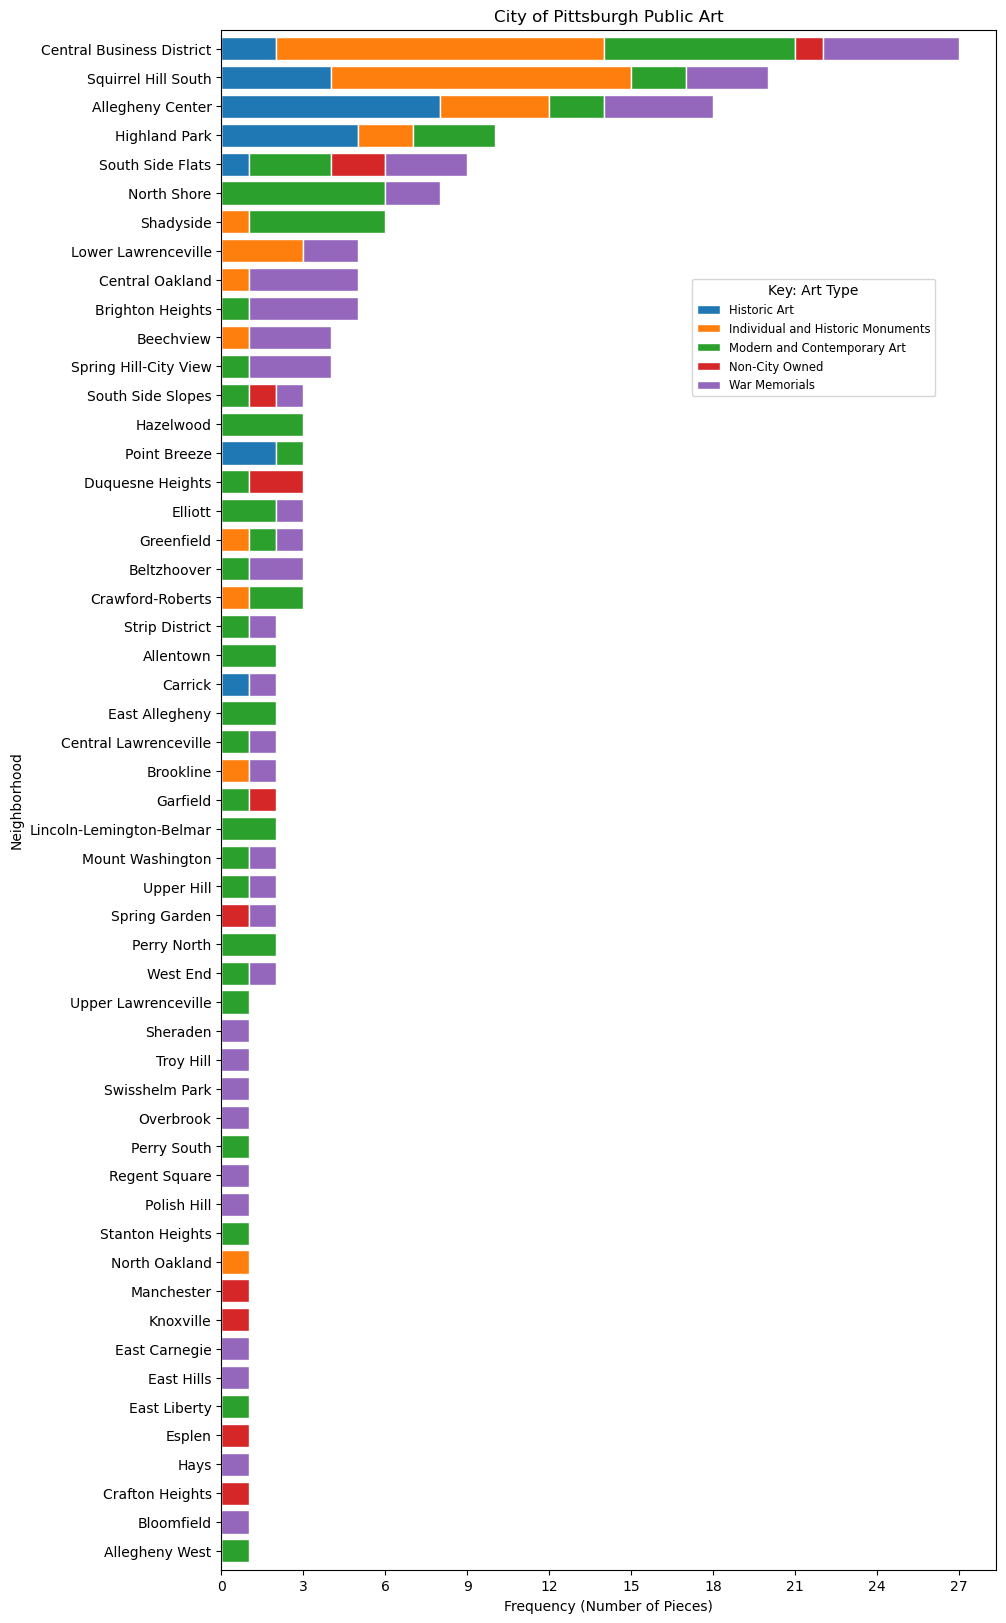

In [42]:
# Group the data by neighborhood, and the type of art 
art_pivot = pd.crosstab(df['neighborhood'], df['art_type'])

# Sort the data based on how much art each neighborhood has
art_pivot['Total Art'] = art_pivot.sum(axis=1)
sorted_art = art_pivot.sort_values(by='Total Art')

# Creates the graph
ax = sorted_art.drop(columns='Total Art').plot(
    kind='barh', 
    stacked=True, 
    figsize=(10, 20), 
    width=0.8,
    title="City of Pittsburgh Public Art",
    edgecolor='white'
)

# Makes bucket range of 3, instead of 5 (more inclusive in the graph)
ax.set_xticks(range(0, 30, 3))

# Labels the x and y axes
ax.set_xlabel("Frequency (Number of Pieces)")
ax.set_ylabel("Neighborhood")

# Moves the legend on the graph
ax.legend(title="Key: Art Type", loc='center left', bbox_to_anchor=(0.60, 0.80), fontsize='small')
plt.show()

The metrics that I chose for my dataset were the types of art (the neighborhood had to have variety), and it needed to have an abundance of art as well. Based on these metrics the Central Business District was the best neighborhood; however, that doesn't work in the grand scheme as the neighborhood does not house many people, as it mainly is filled with corporations and chains, not small businesses or homes, which more accurately portray Pittsburgh. Due to these limitations I found that Squirrel Hill would most accurately represent Pittsburgh as it has a good mix of homes, apartments, small businesses, and corporations/chains in the area. The area has a good mix of art only missing one category from the list and has about 20 pieces of art around the neighborhood. 


## Conclusion

When looking at the three of our datasets together we found that we all had different top neighborhoods based off of our own metrics. We then had to compare and look at multiple factors to decide what would ultimately be the best neighborhood in Pittsburgh. For the city parks the best neighborhood was Squirrel Hill (2021), for walkability it was Central Oakland (2010), and for public art it was the Central Business District (2024). We found that it was important to take into consideration the last time that each of our datasets were updated in order to have the most accurate representation of Pittsburgh currently. The second best neighborhood for the public art dataset was Squirrel Hill, which compared to with the city parks dataset it was determined that we would name it the best neighborhood in Pittsburgh, despite the fact that the walkability dataset had ranked it 24th. We felt that we should name Squirrel Hill the best neighborhood due to the fact that based on the two most updated datasets ranked it top 2, while the older dataset had ranked it significantly lower, we felt it did not hold as much significance. When doing our own research as to why Squirrel Hill would be ranked this low we looked into what was happening in Pittsburgh when the dataset was made. Through our findings it showed that there was a large snowstorm in 2010 which majorly impacted the people and businesses in Squirrel Hill during that time. Taking all of these factors into account our group had come to the conclusion that Squirrel Hill was the best neighborhood in Pittsburgh based on the majority of the datasets having the neighborhood ranked highly, and checking the metrics that we had placed. 
